In [1]:
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
df = pd.read_csv("supermarket_sales - Sheet1.csv")

In [3]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='str')

In [4]:
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

df.head()

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5%,total,date,time,payment,cogs,gross_margin_percentage,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [5]:
df["date"] = pd.to_datetime(df["date"], format="mixed")

df["date"].head()

0   2019-01-05
1   2019-03-08
2   2019-03-03
3   2019-01-27
4   2019-02-08
Name: date, dtype: datetime64[us]

In [6]:
df["month"]=df["date"].dt.month

df["month"].head()

0    1
1    3
2    3
3    1
4    2
Name: month, dtype: int32

In [7]:
df.columns

Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender',
       'product_line', 'unit_price', 'quantity', 'tax_5%', 'total', 'date',
       'time', 'payment', 'cogs', 'gross_margin_percentage', 'gross_income',
       'rating', 'month'],
      dtype='str')

In [8]:
revenue_by_product = df.groupby("product_line")["total"].sum().round(2).reset_index().rename(columns={"total": "total revenue"})
print(revenue_by_product)

             product_line  total revenue
0  Electronic accessories       54337.53
1     Fashion accessories       54305.90
2      Food and beverages       56144.84
3       Health and beauty       49193.74
4      Home and lifestyle       53861.91
5       Sports and travel       55122.83


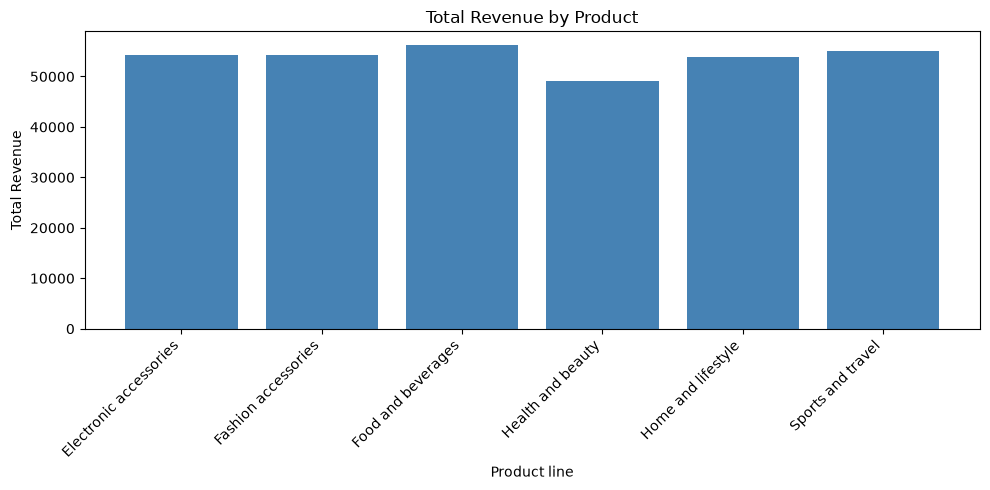

In [9]:
plt.figure(figsize=(10, 5))

plt.bar(revenue_by_product["product_line"], revenue_by_product["total revenue"], color= "steelblue")

plt.title("Total Revenue by Product")
plt.xlabel("Product line")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
print("Revenue by Month")

Revenue by Month


In [11]:
revenue_by_month = df.groupby("month")["total"].sum().round(2).reset_index()

print(revenue_by_month)

   month      total
0      1  116291.87
1      2   97219.37
2      3  109455.51


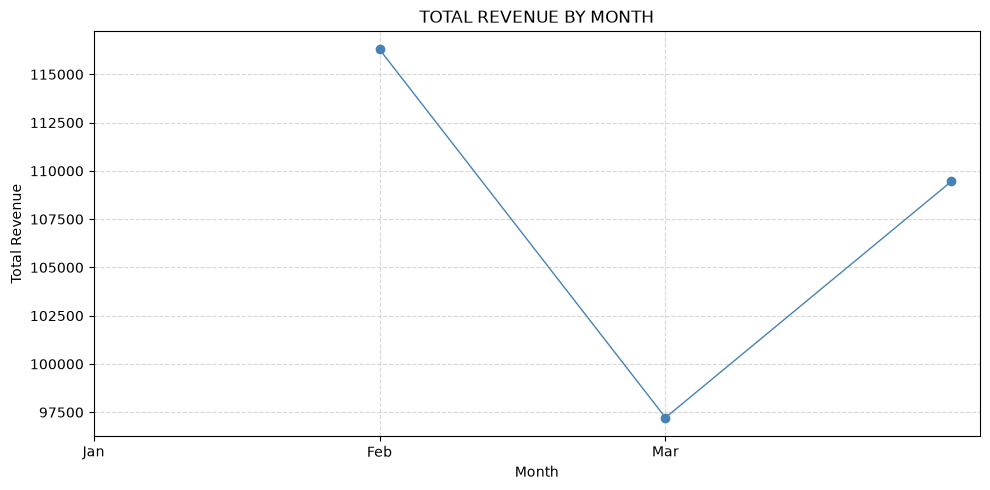

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(revenue_by_month["month"], revenue_by_month["total"], marker='o', linewidth=1, color='steelblue')
plt.title("TOTAL REVENUE BY MONTH")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(revenue_by_month.index, ["Jan", "Feb", 'Mar'])

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()